<a href="https://colab.research.google.com/github/anshuman-dataverse/Gen_ai/blob/main/M4_Lab1_GenAI_Triage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- applied-genai-header -->
<div style="background: linear-gradient(135deg, #1e4b8f 0%, #2d6cb8 100%); color: white; padding: 24px; border-radius: 12px; font-family: 'Segoe UI', sans-serif; margin-bottom: 16px;">
  <div style="font-size: 12px; opacity: 0.85; letter-spacing: 1.5px; text-transform: uppercase;">Applied Generative AI · IE 5373</div>
  <h1 style="margin: 8px 0 4px 0; font-size: 28px; font-weight: 600;">M4 Lab 1 — GenAI Triage Assistant</h1>
  <div style="font-size: 14px; opacity: 0.9;">Classification, structured output, and a simple medical triage app</div>
  <div style="margin-top: 12px; font-size: 12px; opacity: 0.8;">Prof. Mohammad Dehghani · Northeastern University</div>
</div>

> **📌 Note on models.** This lab references specific LLM versions (e.g. `gpt-5`, `gpt-5-mini`).
> Models update quickly — you are welcome (and encouraged) to swap in any newer OpenAI / Anthropic / Google model you have access to.
> The default model is set in one place: `DEFAULT_CHAT_MODEL` inside `utils.py`. Change it there and every cell follows.


In [ ]:
# === Shared lab setup: utils.py + API key + sticky lab pill ===
# Downloads the shared utilities (pretty_print, model constants, key loader,
# lab_pill) from the AppliedGenAI repo so every notebook stays small and
# consistent. The API key is read from a Colab secret named OPENAI_API_KEY
# (set it once under Colab → 🔑 → "Notebook access" — same name in every lab).
import os
if not os.path.exists("utils.py"):
    !wget -q https://raw.githubusercontent.com/mdehghani86/AppliedGenAI/main/utils.py -O utils.py

from utils import (
    pretty_print,
    DEFAULT_CHAT_MODEL,   # e.g. "gpt-5"  — main reasoning model
    DEFAULT_MINI_MODEL,   # e.g. "gpt-5-mini"  — cheaper / faster default
    DEFAULT_EMBED_MODEL,  # e.g. "text-embedding-3-small"
    get_openai_key,
    lab_pill,
)

lab_pill('M4 Lab 1 — GenAI Triage Assistant')        # sticky banner so you always see which lab you're in
get_openai_key(verify=True)    # loads the key + pings OpenAI to confirm it works


<a href="https://colab.research.google.com/github/mdehghani86/AppliedGenAI/blob/main/M4_Lab1_GenAI_Triage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); color: white; padding: 25px; margin-bottom: 20px; text-align: center; border-radius: 10px;">
<h1 style="font-size: 32px; margin-bottom: 10px;">GenAI-Assisted Medical Triage System</h1>
<p style="margin: 0; font-size: 16px;">Enhancing clinical decision support with artificial intelligence</p>
<p style="margin-top: 10px; font-size: 18px; font-weight: bold;">Dr. Dehghani</p>
</div>

<div style="background: #f0f5ff; border-radius: 12px; padding: 20px; margin-bottom: 25px; border: 1px solid #0055d4;">
<h2 style="color: #0055d4; margin-top: 0; font-size: 24px; padding-bottom: 10px; border-bottom: 2px solid #0055d4;">Overview</h2>

<p style="line-height: 1.8; font-size: 16px;">This notebook demonstrates a GenAI-assisted medical triage system with two key components:</p>

<div style="display: flex; flex-wrap: wrap; gap: 15px; margin-top: 15px;">
    <div style="display: flex; align-items: center; background-color: white; padding: 10px 15px; border-radius: 8px; border-left: 3px solid #0055d4;"><span style="font-size: 24px; margin-right: 10px;">👤</span> <span><strong>Patient Generation</strong>: Using Gemini to create synthetic patient profiles</span></div>
    <div style="display: flex; align-items: center; background-color: white; padding: 10px 15px; border-radius: 8px; border-left: 3px solid #0055d4;"><span style="font-size: 24px; margin-right: 10px;">🏥</span> <span><strong>Triage Decision-Making</strong>: Using ChatGPT to evaluate and assign triage levels</span></div>
</div>

<p style="margin-top: 20px; font-style: italic; color: #0055d4;">The system generates patient information, processes it through a triage model, and provides clinical rationale for each decision.</p>

<hr style="margin: 20px 0; border: 0; border-top: 1px solid #ddd;">

<p style="font-size: 14px; color: #666;"><strong style="color: #f39c12;">Note:</strong> This demonstration is for educational purposes only and requires significant modifications for real-world clinical applications.</p>
</div>

<div style="background: white; border-radius: 12px; padding: 20px; margin-bottom: 25px; border: 1px solid #e0e0e0;">
<h2 style="color: #0055d4; margin-top: 0; font-size: 24px; padding-bottom: 10px; border-bottom: 2px solid #0055d4;">Learning Objectives</h2>

<ul style="line-height: 1.8; font-size: 16px;">
<li>Demonstrating the use of GenAI for medical applications</li>
<li>Implementing prompt engineering techniques in healthcare contexts</li>
<li>Integrating multiple AI models (Gemini and ChatGPT) in LangChain</li>
<li>Understanding AI-assisted clinical decision support systems</li>
</ul>
</div>


<div style="margin-bottom: 25px; padding-left: 15px; border-left: 4px solid #0055d4;">
<h2 style="color: #0055d4; margin-top: 0; font-size: 24px; padding-bottom: 10px; border-bottom: 2px solid #e0e0e0;">Imports and Setup</h2>

<p style="line-height: 1.6; font-size: 16px; color: #666;">Import necessary libraries and configure API access for Gemini and OpenAI models.</p>
</div>

In [3]:
# 📦 Importing Libraries
import os # Operating system interactions (basic)
import json # Working with JSON data (basic)
import time # Time-related functions (basic)
import random # Generating random numbers (basic)
import pandas as pd # Data manipulation and analysis (major)
import matplotlib.pyplot as plt # Plotting and visualization (major)
import seaborn as sns # Enhanced data visualization (major)
from datetime import datetime # Date and time operations (basic)
from google.colab import userdata # Secure access to Colab user data (Colab specific)
import google.generativeai as genai # Interacting with Google's GenAI models (major)
import openai # Interacting with OpenAI models (major)
from IPython.display import display, Markdown, HTML # Displaying rich output in notebooks (notebook specific)

# Set visual styles
plt.style.use('ggplot')
sns.set(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


<div style="background: white; border-radius: 12px; padding: 20px; margin-bottom: 25px; border: 1px solid #0055d4;">
<h3 style="color: #0055d4; margin-top: 0; font-size: 20px;">API Keys Setup</h3>
<p>Configure your API keys for Gemini and OpenAI models. For security, use Colab Secrets whenever possible.</p>
</div>

In [7]:
# 🔑 Get API keys from Colab Secrets
# You need to set these up in your Colab environment under "Secrets"

# Uncomment these lines when running in Colab
# (api key handled by get_openai_key() in setup cell)
genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))

# For demonstration purposes, you can set keys directly (not recommended for shared notebooks)
# # (api key handled by get_openai_key() in setup cell)
# genai.configure(api_key="your-gemini-api-key")

print("API keys configured successfully.")
# Use API Key name shoud be OPENAI_API_KEY and GEMINI_API_KEY, otherwise please fix it manually on the code

API keys configured successfully.


<div style="background: linear-gradient(135deg, #f0f5ff 0%, #e6f0ff 100%); border-radius: 12px; padding: 25px; margin-bottom: 25px; border: 1px solid #0055d4;">
<h2 style="color: #0055d4; margin-top: 0; font-size: 24px; padding-bottom: 10px; border-bottom: 2px solid #0055d4;">👨‍⚕️ Patient Generation Functions</h2>
<p style="line-height: 1.6;">These functions use the Gemini model to generate synthetic patient profiles with realistic medical details for emergency department triage simulation.</p>
<div style="background-color: white; padding: 15px; border-radius: 8px; margin-top: 15px;">
    <h3 style="color: #0055d4; margin-top: 0;">Key Functions:</h3>
    <ul style="padding-left: 20px;">
        <li><strong>generate_patient()</strong>: Creates synthetic patient data using Gemini's generative AI, including demographics, symptoms, medical history, and vital signs</li>
        <li><strong>format_patient_data()</strong>: Transforms the generated JSON data into a readable format for display</li>
    </ul>
</div>
<div style="background-color: white; padding: 15px; border-radius: 8px; margin-top: 15px;">
    <h3 style="color: #0055d4; margin-top: 0;">Triage Classification:</h3>
    <p>The system uses the Emergency Severity Index (ESI) with 5 levels:</p>
    <ol style="padding-left: 20px;">
        <li><span style="color: #ff0000;"><strong>Immediate (Red)</strong></span>: Life-threatening conditions requiring immediate attention</li>
        <li><span style="color: #ff9900;"><strong>Very Urgent (Orange)</strong></span>: Potentially life-threatening, requires rapid assessment</li>
        <li><span style="color: #ffcc00;"><strong>Urgent (Yellow)</strong></span>: Serious but stable condition requiring timely assessment</li>
        <li><span style="color: #00cc00;"><strong>Standard (Green)</strong></span>: Standard cases with no immediate danger</li>
        <li><span style="color: #0099ff;"><strong>Non-Urgent (Blue)</strong></span>: Minor conditions that can safely wait</li>
    </ol>
</div>
<div style="background-color: #fff9e6; padding: 15px; border-radius: 8px; margin-top: 15px; border-left: 4px solid #ffc107;">
    <h3 style="color: #996600; margin-top: 0;">Notes on Implementation:</h3>
    <ul style="padding-left: 20px; line-height: 1.7;">
        <li><strong>Prompt Design:</strong> The prompt uses a Chain-of-Thought approach to guide the LLM through generating diverse and realistic patient profiles. It includes specific distribution instructions (e.g., 1 in 5 cases should be pediatric) to ensure variety.</li>
        <li><strong>Limitations:</strong> Despite careful prompt engineering, generated data may still exhibit bias and might not perfectly represent all age groups, genders, or medical conditions. Multiple rounds of iteration were needed to improve the prompt, but further enhancements are possible.</li>
        <li><strong>Error Handling:</strong> The code includes robust error handling to manage potential issues with LLM responses, including JSON parsing and formatting challenges.</li>
        <li><strong>Consistency Controls:</strong> The prompt includes instructions to ensure medical history, medications, and vital signs are internally consistent and appropriate for the patient's profile.</li>
        <li><strong>Response Cleaning:</strong> Special processing is needed to extract clean JSON from the LLM response, as models sometimes include markdown formatting or explanatory text.</li>
    </ul>
</div>
</div>

In [27]:
# Define triage levels
TRIAGE_LEVELS = {
    1: "Immediate (Red): Life-threatening conditions requiring immediate attention",
    2: "Very Urgent (Orange): Potentially life-threatening, requires rapid assessment",
    3: "Urgent (Yellow): Serious but stable condition requiring timely assessment",
    4: "Standard (Green): Standard cases with no immediate danger",
    5: "Non-Urgent (Blue): Minor conditions that can safely wait"
}

def generate_patient(patient_id=None):
    if not patient_id:
        patient_id = f"PT-{datetime.now().strftime('%Y%m%d-%H%M')}-{random.randint(1000, 9999)}"

    prompt = f"""
    You are generating synthetic emergency room patients for a simulation.
    To maximize educational value, you must use a chain-of-thought reasoning strategy (internally, not in output) to ensure variety.

    **Chain-of-Thought Planning (do not include in output):**
    1. Randomly select an age group: infant/toddler (0–3), child (4–12), adolescent (13–18), young adult (19–39), adult (40–64), or elderly (65+). Avoid repeating the same age group in consecutive cases.
    2. Randomly select gender.
    3. Randomly select a chief complaint from a broad range: trauma, infection, psychiatric, allergy, pain, minor injury, medication issue, fever, seizure, behavioral, etc. Do not always choose chest pain or shortness of breath, and avoid repeating the same complaint in back-to-back cases. Make sure to include some mild cases as well.
    4. Out of every 5 cases: 1 should be pediatric, 2 should be under 40, 1 should be over 65, and 1 can be any age.
    5. Out of every 5 cases: only 1 should have a cardiac chief complaint (such as chest pain, myocardial infarction, or shortness of breath).
    6. Match medical history, medications, and allergies to the selected age, gender, and chief complaint. Vary these details between cases.
    7. Ensure the pain score and vital signs are consistent with the scenario, and allow for a wide range of values to show diversity.
    8. Occasionally include ambulance arrivals or accident/trauma cases among the generated patients.


    **OUTPUT REQUIREMENT:**
    ONLY return the JSON object below, nothing else.
    Populate all fields with realistic, non-repetitive, internally-consistent values, matching your planning above.

    {{
      "patient_id": "{patient_id}",
      "age": AGE,
      "sex": "GENDER",
      "chief_complaint": "PRIMARY_COMPLAINT",
      "symptoms": ["SYMPTOM1", "SYMPTOM2", ...],
      "medical_history": ["CONDITION1", "CONDITION2", ...],
      "medications": ["MEDICATION1", "MEDICATION2", ...],
      "allergies": ["ALLERGY1", "ALLERGY2", ...],
      "vitals": {{
        "temperature": TEMP_VALUE,
        "heart_rate": HR_VALUE,
        "blood_pressure": "BP_VALUE",
        "respiratory_rate": RR_VALUE,
        "oxygen_saturation": O2_VALUE
      }},
      "pain_score": PAIN_LEVEL
    }}
    """

    try:
        gemini_model = genai.GenerativeModel('models/gemini-2.5-flash')
        response = gemini_model.generate_content(prompt)
        response_text = response.text.strip()

        # Remove code block markers if present
        if response_text.startswith("```json"):
            response_text = response_text[7:]
        if response_text.startswith("```"):
            response_text = response_text[3:]
        if "```" in response_text:
            response_text = response_text.split("```")[0]

        # Find the first JSON object in the response
        json_start = response_text.find('{')
        json_end = response_text.find('}', json_start)  # Find the first closing }
        bracket_count = 0
        for i, c in enumerate(response_text[json_start:], start=json_start):
            if c == '{':
                bracket_count += 1
            elif c == '}':
                bracket_count -= 1
                if bracket_count == 0:
                    json_end = i + 1
                    break

        if json_start >= 0 and json_end > json_start:
            json_content = response_text[json_start:json_end]
            patient_data = json.loads(json_content)
            return patient_data
        else:
            raise ValueError("Could not extract valid JSON from Gemini response")

    except Exception as e:
        return f"❌ LLM did not respond properly: {e}"



# Function to convert patient data to a readable format
def format_patient_data(patient):
    """
    Formats patient data for display

    Args:
        patient: Dictionary containing patient information

    Returns:
        str: Formatted patient information
    """
    formatted = f"""
    ## Patient ID: {patient['patient_id']}

    **Demographics:** {patient['age']}-year-old {patient['sex']}
    **Chief Complaint:** {patient['chief_complaint']}

    **Symptoms:**
    - {', '.join(patient['symptoms'])}

    **Medical History:**
    - {', '.join(patient['medical_history'])}

    **Medications:**
    - {', '.join(patient['medications'])}

    **Allergies:**
    - {', '.join(patient['allergies'])}

    **Vitals:**
    - Temperature: {patient['vitals']['temperature']}°F
    - Heart Rate: {patient['vitals']['heart_rate']} bpm
    - Blood Pressure: {patient['vitals']['blood_pressure']}
    - Respiratory Rate: {patient['vitals']['respiratory_rate']} breaths/min
    - Oxygen Saturation: {patient['vitals']['oxygen_saturation']}%

    **Pain Score:** {patient['pain_score']}/10
    """
    return formatted

In [28]:
# Generate 2 patients and display them
for i in range(1):
    print(f"\n{'='*50}\nGENERATING PATIENT #{i+1}\n{'='*50}")
    patient = generate_patient()

    # Check if we received an error message
    if isinstance(patient, str):
        pretty_print(str(patient), title="🩺 Patient", theme="yellow")
    else:
        pretty_print(format_patient_data(patient), title="🩺 Formatted Patient Record")


GENERATING PATIENT #1


<div style="background: linear-gradient(135deg, #f0f5ff 0%, #e6f0ff 100%); border-radius: 12px; padding: 25px; margin-bottom: 25px; border: 1px solid #0055d4;">
<h2 style="color: #0055d4; margin-top: 0; font-size: 24px; padding-bottom: 10px; border-bottom: 2px solid #0055d4;">🚑 AI-Powered Triage Decision System</h2>
<p style="line-height: 1.6;">This system uses OpenAI's GPT-4o model to evaluate patient information and recommend appropriate triage levels based on the Emergency Severity Index (ESI).</p>
<div style="background-color: white; padding: 15px; border-radius: 8px; margin-top: 15px;">
    <h3 style="color: #0055d4; margin-top: 0;">Key Functions:</h3>
    <ul style="padding-left: 20px;">
        <li><strong>triage_patient()</strong>: Analyzes patient data using GPT-4o to determine appropriate triage level, confidence score, rationale, and recommended actions</li>
        <li><strong>format_triage_results()</strong>: Creates a color-coded visual representation of the triage decision with clinical rationale</li>
    </ul>
</div>
<div style="background-color: white; padding: 15px; border-radius: 8px; margin-top: 15px;">
    <h3 style="color: #0055d4; margin-top: 0;">How It Works:</h3>
    <ol style="padding-left: 20px;">
        <li>Patient data is converted to a structured text format</li>
        <li>A specialized prompt instructs the LLM to act as an experienced emergency triage nurse</li>
        <li>The system provides the ESI triage scale definitions (Levels 1-5)</li>
        <li>GPT-4o analyzes the patient information and returns a structured JSON response</li>
        <li>Response includes triage level, confidence score, clinical rationale, and recommended actions</li>
        <li>Error handling ensures a fallback triage decision (Level 3) if the API fails</li>
        <li>Results are formatted with color-coding based on severity level</li>
    </ol>
</div>
<div style="background-color: white; padding: 15px; border-radius: 8px; margin-top: 15px;">
    <h3 style="color: #0055d4; margin-top: 0;">Prompt Design:</h3>
    <p>The prompt is carefully engineered to:</p>
    <ul style="padding-left: 20px;">
        <li>Establish the context (emergency triage nurse role)</li>
        <li>Provide clear definitions of each triage level</li>
        <li>Present structured patient information</li>
        <li>Request specific output format with triage level, confidence, rationale, and recommendations</li>
        <li>Emphasize evidence-based decision making considering vitals, symptoms, and medical history</li>
    </ul>
</div>
<div style="background-color: #fff0f0; padding: 15px; border-radius: 8px; margin-top: 15px; border-left: 4px solid #ff6b6b;">
    <h3 style="color: #d32f2f; margin-top: 0;">⚠️ Important Limitations:</h3>
    <ul style="padding-left: 20px; line-height: 1.7;">
        <li><strong>Confidence Level Accuracy:</strong> The confidence scores provided by the LLM may not accurately reflect actual clinical certainty. These values tend to be arbitrarily high and should not be solely relied upon for determining decision quality.</li>
        <li><strong>Clinical Validation Required:</strong> All LLM-based triage decisions must be validated by qualified healthcare professionals before application in any clinical setting. This system is for research and educational purposes only.</li>
        <li><strong>Potential Bias:</strong> The LLM may exhibit biases in its decision-making process based on its training data, potentially leading to systematic disparities in triage recommendations for different demographic groups.</li>
        <li><strong>Incomplete Information Handling:</strong> The system has limited ability to request additional information that would be standard in real triage scenarios, potentially leading to suboptimal decisions when critical data is missing.</li>
    </ul>
</div>
</div>

In [11]:
def triage_patient(patient_data):
    """
    Determine triage level using OpenAI's ChatGPT

    Args:
        patient_data: Dictionary containing patient information

    Returns:
        dict: Triage decision including level, confidence, and rationale
    """
    # Convert patient data to text format for the prompt
    patient_text = json.dumps(patient_data, indent=2)

    # Create prompt for OpenAI
    prompt = f"""
    You are an experienced emergency department triage nurse.
    Based on the following patient information, assign an appropriate triage level using the Emergency Severity Index (ESI) from 1-5:

    - Level 1 (Immediate/Red): Life-threatening conditions requiring immediate treatment
    - Level 2 (Very Urgent/Orange): High risk, potentially life-threatening, rapid assessment needed
    - Level 3 (Urgent/Yellow): Serious but stable condition, requires timely assessment
    - Level 4 (Standard/Green): Standard cases, no immediate danger
    - Level 5 (Non-Urgent/Blue): Minor conditions that can safely wait

    PATIENT INFORMATION:
    {patient_text}

    Provide your assessment in the following JSON format:
    {{
      "triage_level": LEVEL_NUMBER,
      "triage_category": "CATEGORY_NAME",
      "confidence": CONFIDENCE_SCORE_0_TO_1,
      "rationale": "DETAILED_CLINICAL_RATIONALE",
      "recommended_actions": ["ACTION1", "ACTION2", ...]
    }}

    Ensure your triage decision is evidence-based and considers the patient's vitals, symptoms, and medical history.
    """

    try:
        # Call OpenAI API
        response = openai.chat.completions.create(
            model=DEFAULT_CHAT_MODEL,  # or gpt-3.5-turbo
            messages=[
                {"role": "system", "content": "You are an experienced emergency medicine triage nurse. Provide accurate, evidence-based triage decisions."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2,
            max_tokens=1000
        )

        # Extract the response text
        response_text = response.choices[0].message.content

        # Find JSON content (between curly braces)
        json_start = response_text.find('{')
        json_end = response_text.rfind('}') + 1

        if json_start >= 0 and json_end > 0:
            json_content = response_text[json_start:json_end]
            triage_decision = json.loads(json_content)
            return triage_decision
        else:
            raise ValueError("Could not extract valid JSON from API response")

    except Exception as e:
        print(f"Error in triage decision: {e}")
        # Return fallback triage data
        return {
            "triage_level": 3,
            "triage_category": "Urgent (Yellow)",
            "confidence": 0.75,
            "rationale": "Fallback triage decision due to API error",
            "recommended_actions": ["Assessment by physician", "Vital signs monitoring"]
        }

# Function to format triage results
def format_triage_results(triage_result):
    """
    Formats triage results for display

    Args:
        triage_result: Dictionary containing triage decision

    Returns:
        str: Formatted triage decision
    """
    # Define color mapping for triage levels
    triage_colors = {
        1: "#ff0000",  # Red
        2: "#ff9900",  # Orange
        3: "#ffff00",  # Yellow
        4: "#00cc00",  # Green
        5: "#0099ff"   # Blue
    }

    level = triage_result['triage_level']
    color = triage_colors.get(level, "#999999")

    formatted = f"""
    ## Triage Decision

    <div style="background-color: {color}; color: {'white' if level <= 2 else 'black'}; padding: 10px; border-radius: 5px; margin: 10px 0;">
    <h3>Level {level}: {triage_result['triage_category']}</h3>
    <p><strong>Confidence:</strong> {triage_result['confidence']*100:.1f}%</p>
    </div>

    **Clinical Rationale:**
    {triage_result['rationale']}

    **Recommended Actions:**
    - {', '.join(triage_result['recommended_actions'])}
    """
    return formatted

<div style="background: linear-gradient(135deg, #e6f7ff 0%, #d1edff 100%); border-radius: 12px; padding: 20px; margin-bottom: 25px; border: 1px solid #0066cc;">
<h2 style="color: #0066cc; margin-top: 0; font-size: 24px; padding-bottom: 10px; border-bottom: 2px solid #0066cc;">🔬 Triage Experiment Runner</h2>
<p style="line-height: 1.6;">The <code>run_triage_experiment()</code> function coordinates the end-to-end triage simulation process, from patient generation to result analysis.</p>
<div style="background-color: white; padding: 15px; border-radius: 8px; margin-top: 15px;">
    <h3 style="color: #0066cc; margin-top: 0;">Key Features:</h3>
    <ul style="padding-left: 20px;">
        <li><strong>Batch Processing:</strong> Handles multiple patient cases (default: 10) in sequence</li>
        <li><strong>Performance Tracking:</strong> Measures and records time spent on patient generation and triage</li>
        <li><strong>Visualization:</strong> Displays formatted patient data and color-coded triage decisions</li>
        <li><strong>Data Collection:</strong> Compiles demographics and triage results into a structured DataFrame</li>
    </ul>
</div>
<div style="background-color: #f0f8ff; padding: 15px; border-radius: 8px; margin-top: 15px; border-left: 4px solid #0066cc;">
    <h3 style="color: #0055aa; margin-top: 0;">Usage Notes:</h3>
    <p style="margin-bottom: 8px;">Control the experiment with these parameters:</p>
    <ul style="padding-left: 20px; margin-bottom: 0;">
        <li><code>num_patients</code>: Set the sample size (higher values provide better distribution analysis)</li>
        <li><code>verbose</code>: Enable/disable detailed output for each patient case</li>
    </ul>
</div>
</div>

In [12]:
def run_triage_experiment(num_patients=10, verbose=True):
    """
    Run the triage experiment for a specified number of patients

    Args:
        num_patients: Number of synthetic patients to generate and triage
        verbose: Whether to display detailed information for each patient

    Returns:
        DataFrame: Results of all triage decisions
    """
    results = []

    print(f"Starting GenAI-Assisted Medical Triage Experiment with {num_patients} patients")
    print("=" * 80)

    for i in range(num_patients):
        print(f"\nProcessing Patient {i+1}/{num_patients}...")

        # Generate patient data
        start_time = time.time()
        patient = generate_patient()
        patient_gen_time = time.time() - start_time

        # Perform triage decision
        start_time = time.time()
        triage_decision = triage_patient(patient)
        triage_time = time.time() - start_time

        # Store results
        results.append({
            "patient_id": patient["patient_id"],
            "age": patient["age"],
            "sex": patient["sex"],
            "chief_complaint": patient["chief_complaint"],
            "triage_level": triage_decision["triage_level"],
            "triage_category": triage_decision["triage_category"],
            "confidence": triage_decision["confidence"],
            "patient_gen_time": patient_gen_time,
            "triage_time": triage_time
        })

        # Display verbose output if requested
        if verbose:
            display(Markdown(format_patient_data(patient)))
            display(HTML(format_triage_results(triage_decision)))
            print("-" * 80)

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)

    print("\nExperiment completed successfully!")
    return results_df

<div style="background: white; border-radius: 12px; padding: 20px; margin-bottom: 25px; border: 1px solid #0055d4;">
<h3 style="color: #0055d4; margin-top: 0; font-size: 20px;">📊 Results Analysis</h3>
<p>This function analyzes and visualizes the experiment results with charts and statistics.</p>
</div>

In [23]:
def analyze_results(results_df):
    """
    Analyze and visualize the results of the triage experiment

    Args:
        results_df: DataFrame containing experiment results

    Returns:
        None (displays visualizations)
    """
    # Print summary statistics
    print("\n=== Triage Experiment Summary ===\n")
    print(f"Total patients processed: {len(results_df)}")

    # Distribution of triage levels
    level_counts = results_df['triage_level'].value_counts().sort_index()

    print("\nTriage Level Distribution:")
    for level, count in level_counts.items():
        print(f"Level {level} ({TRIAGE_LEVELS[level].split(':')[0]}): {count} patients ({count/len(results_df)*100:.1f}%)")

    # Average processing times
    print(f"\nAverage patient generation time: {results_df['patient_gen_time'].mean():.2f} seconds")
    print(f"Average triage decision time: {results_df['triage_time'].mean():.2f} seconds")
    print(f"Total average processing time per patient: {(results_df['patient_gen_time'] + results_df['triage_time']).mean():.2f} seconds")

    # Create visualizations
    plt.figure(figsize=(15, 10))

    # Triage level distribution
    plt.subplot(2, 2, 1)
    colors = ['#ff0000', '#ff9900', '#ffff00', '#00cc00', '#0099ff']
    bars = plt.bar(level_counts.index, level_counts.values, color=[colors[i-1] for i in level_counts.index])
    plt.title('Distribution of Triage Levels')
    plt.xlabel('Triage Level')
    plt.ylabel('Number of Patients')
    plt.xticks(level_counts.index)

    # Add percentage labels to bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height/len(results_df)*100:.1f}%', ha='center')

    # Age distribution by triage level
    plt.subplot(2, 2, 2)
    sns.boxplot(x='triage_level', y='age', data=results_df, palette=colors[:len(level_counts)])
    plt.title('Age Distribution by Triage Level')
    plt.xlabel('Triage Level')
    plt.ylabel('Age')

    # Confidence scores by triage level
    plt.subplot(2, 2, 3)
    sns.boxplot(x='triage_level', y='confidence', data=results_df, palette=colors[:len(level_counts)])
    plt.title('Confidence Scores by Triage Level')
    plt.xlabel('Triage Level')
    plt.ylabel('Confidence Score')
    plt.ylim(0, 1)

    # Processing time
    plt.subplot(2, 2, 4)
    time_data = pd.DataFrame({
        'Patient Generation': results_df['patient_gen_time'],
        'Triage Decision': results_df['triage_time']
    })
    time_data.plot(kind='bar', stacked=True, ax=plt.gca(), figsize=(10, 6))
    plt.title('Processing Time by Patient')
    plt.xlabel('Patient Index')
    plt.ylabel('Time (seconds)')
    plt.xticks([])
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # Display final conclusions
    print("\n=== Key Findings ===")
    most_common_level = level_counts.idxmax()
    print(f"- Most common triage level: Level {most_common_level} ({TRIAGE_LEVELS[most_common_level].split(':')[0]})")
    print(f"- Average model confidence: {results_df['confidence'].mean()*100:.1f}%")
    print(f"- Gender distribution: {results_df['sex'].value_counts().to_dict()}")

    # Chief complaints analysis
    complaints = results_df['chief_complaint'].value_counts()
    print(f"- Top chief complaints: {', '.join(complaints.index[:3])}")

    # Efficiency assessment
    print(f"- Total processing time for all {len(results_df)} patients: {results_df['patient_gen_time'].sum() + results_df['triage_time'].sum():.2f} seconds")

<div style="background: linear-gradient(135deg, #f0f5ff 0%, #e6f0ff 100%); border-radius: 12px; padding: 25px; margin-bottom: 25px; border: 1px solid #0055d4;">
<h2 style="color: #0055d4; margin-top: 0; font-size: 24px; padding-bottom: 10px; border-bottom: 2px solid #0055d4;">▶️ Execute the Experiment</h2>

<p style="line-height: 1.6;">Run this cell to execute the triage experiment with 10 synthetic patients.</p>
<p><strong>Note:</strong> This will make API calls to both Gemini and OpenAI which may incur charges based on your usage tiers.</p>

<ul style="padding-left: 25px; margin-top: 15px; color: #555;">
  <li><strong>Execution time:</strong> The complete experiment typically takes 3-5 minutes to run depending on API response times</li>
  <li><strong>Output:</strong> Results will be stored in the <code>experiment_results</code> variable for further analysis</li>
</ul>
</div>

Starting GenAI-Assisted Medical Triage Experiment with 10 patients

Processing Patient 1/10...

==== PATIENT INFORMATION ====
{
  "patient_id": "PT-20241027-1422-8910",
  "age": 8,
  "sex": "Male",
  "chief_complaint": "Right forearm pain and deformity after falling from playground equipment",
  "symptoms": [
    "Severe sharp pain in right forearm",
    "Visible swelling and mild bruising",
    "Inability to rotate wrist or bear weight on right arm"
  ],
  "medical_history": [
    "Mild intermittent asthma"
  ],
  "medications": [
    "Albuterol HFA inhaler (90 mcg, 2 puffs as needed for wheezing)"
  ],
  "allergies": [
    "Penicillin"
  ],
  "vitals": {
    "temperature": 98.4,
    "heart_rate": 115,
    "blood_pressure": "106/68",
    "respiratory_rate": 22,
    "oxygen_saturation": 99
  },
  "pain_score": 7
}

==== AI TRIAGE SUGGESTION ====
Level 3: Urgent/Yellow
Confidence: 90.0%
Rationale: The patient is an 8-year-old male presenting with severe pain and deformity in the right f


    ## Patient ID: PT-20241027-1422-8910

    **Demographics:** 8-year-old Male
    **Chief Complaint:** Right forearm pain and deformity after falling from playground equipment

    **Symptoms:**
    - Severe sharp pain in right forearm, Visible swelling and mild bruising, Inability to rotate wrist or bear weight on right arm

    **Medical History:**
    - Mild intermittent asthma

    **Medications:**
    - Albuterol HFA inhaler (90 mcg, 2 puffs as needed for wheezing)

    **Allergies:**
    - Penicillin

    **Vitals:**
    - Temperature: 98.4°F
    - Heart Rate: 115 bpm
    - Blood Pressure: 106/68
    - Respiratory Rate: 22 breaths/min
    - Oxygen Saturation: 99%

    **Pain Score:** 7/10
    

--------------------------------------------------------------------------------

Processing Patient 2/10...

==== PATIENT INFORMATION ====
{
  "patient_id": "PT-20260520-0300-4321",
  "age": 74,
  "sex": "Female",
  "chief_complaint": "Fall in garden with left wrist pain and swelling",
  "symptoms": [
    "Moderate to severe left wrist pain",
    "Visible swelling and mild bruising of the left wrist",
    "Difficulty moving left hand and fingers due to pain"
  ],
  "medical_history": [
    "Osteoporosis",
    "Primary Hypertension"
  ],
  "medications": [
    "Alendronate 70mg weekly",
    "Lisinopril 10mg daily"
  ],
  "allergies": [
    "Penicillin (rash)"
  ],
  "vitals": {
    "temperature": 36.8,
    "heart_rate": 82,
    "blood_pressure": "138/84",
    "respiratory_rate": 16,
    "oxygen_saturation": 98
  },
  "pain_score": 6
}

==== AI TRIAGE SUGGESTION ====
Level 3: Urgent/Yellow
Confidence: 90.0%
Rationale: The patient is a 74-year-old female with a fall resulting in moderate


    ## Patient ID: PT-20260520-0300-4321

    **Demographics:** 74-year-old Female
    **Chief Complaint:** Fall in garden with left wrist pain and swelling

    **Symptoms:**
    - Moderate to severe left wrist pain, Visible swelling and mild bruising of the left wrist, Difficulty moving left hand and fingers due to pain

    **Medical History:**
    - Osteoporosis, Primary Hypertension

    **Medications:**
    - Alendronate 70mg weekly, Lisinopril 10mg daily

    **Allergies:**
    - Penicillin (rash)

    **Vitals:**
    - Temperature: 36.8°F
    - Heart Rate: 82 bpm
    - Blood Pressure: 138/84
    - Respiratory Rate: 16 breaths/min
    - Oxygen Saturation: 98%

    **Pain Score:** 6/10
    

--------------------------------------------------------------------------------

Processing Patient 3/10...

==== PATIENT INFORMATION ====
{
  "patient_id": "PT-20260520-0300-2869",
  "age": 7,
  "sex": "Male",
  "chief_complaint": "Right wrist deformity and pain after falling from playground monkey bars",
  "symptoms": [
    "Severe pain in the right wrist",
    "Visible swelling and deformity of the distal forearm",
    "Guarding of the right arm",
    "Mild anxiety and crying"
  ],
  "medical_history": [
    "Attention-Deficit/Hyperactivity Disorder (ADHD)",
    "Mild intermittent asthma"
  ],
  "medications": [
    "Methylphenidate 10mg daily",
    "Albuterol HFA inhaler 90mcg as needed"
  ],
  "allergies": [
    "Amoxicillin (hives)"
  ],
  "vitals": {
    "temperature": 98.4,
    "heart_rate": 112,
    "blood_pressure": "104/62",
    "respiratory_rate": 22,
    "oxygen_saturation": 99
  },
  "pain_score": 7
}

==== AI TRIAGE SUGGESTION ====
Level 3: Urgent/Yellow
Confidence: 90.

...


    ## Patient ID: PT-20260520-0302-5156

    **Demographics:** 78-year-old Female
    **Chief Complaint:** Right hip pain following a mechanical fall

    **Symptoms:**
    - Inability to bear weight on the right leg, Severe localized pain in the right groin and hip, External rotation and shortening of the right lower extremity

    **Medical History:**
    - Osteoporosis, Essential hypertension, Mild cognitive impairment

    **Medications:**
    - Alendronate 70 mg weekly, Lisinopril 10 mg daily, Donepezil 5 mg daily, Calcium carbonate 500 mg daily

    **Allergies:**
    - Penicillin (anaphylaxis)

    **Vitals:**
    - Temperature: 98.2°F
    - Heart Rate: 92 bpm
    - Blood Pressure: 146/88
    - Respiratory Rate: 18 breaths/min
    - Oxygen Saturation: 97%

    **Pain Score:** 8/10
    

--------------------------------------------------------------------------------

Processing Patient 10/10...

==== PATIENT INFORMATION ====
{
  "patient_id": "PT-20260520-0302-3960",
  "age": 2,
  "sex": "Male",
  "chief_complaint": "High fever and spreading red rash",
  "symptoms": [
    "Fever",
    "Maculopapular rash on trunk and limbs",
    "Irritability",
    "Poor appetite",
    "Mild rhinorrhea"
  ],
  "medical_history": [
    "Atopic dermatitis"
  ],
  "medications": [
    "Acetaminophen infant drops (as needed for fever)",
    "Hydrocortisone 1% cream (topical as needed)"
  ],
  "allergies": [
    "Amoxicillin"
  ],
  "vitals": {
    "temperature": 39.4,
    "heart_rate": 135,
    "blood_pressure": "94/58",
    "respiratory_rate": 28,
    "oxygen_saturation": 98
  },
  "pain_score": 5
}

==== AI TRIAGE SUGGESTION ====
Level 2: Very Urgent/Orange
Confidence: 90.0%
Rationale: The patient is a 2-year-old male presenting with a high fever (39.4°C) and a spreading maculopapular r


    ## Patient ID: PT-20260520-0302-3960

    **Demographics:** 2-year-old Male
    **Chief Complaint:** High fever and spreading red rash

    **Symptoms:**
    - Fever, Maculopapular rash on trunk and limbs, Irritability, Poor appetite, Mild rhinorrhea

    **Medical History:**
    - Atopic dermatitis

    **Medications:**
    - Acetaminophen infant drops (as needed for fever), Hydrocortisone 1% cream (topical as needed)

    **Allergies:**
    - Amoxicillin

    **Vitals:**
    - Temperature: 39.4°F
    - Heart Rate: 135 bpm
    - Blood Pressure: 94/58
    - Respiratory Rate: 28 breaths/min
    - Oxygen Saturation: 98%

    **Pain Score:** 5/10
    

--------------------------------------------------------------------------------

Experiment completed successfully!

=== Triage Experiment Summary ===

Total patients processed: 10

Triage Level Distribution:
Level 2 (Very Urgent (Orange)): 4 patients (40.0%)
Level 3 (Urgent (Yellow)): 4 patients (40.0%)
Level 4 (Standard (Green)): 2 patients (20.0%)

Average patient generation time: 7.82 seconds
Average triage decision time: 8.49 seconds
Total average processing time per patient: 16.31 seconds


/tmp/ipykernel_2728/2058656404.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='triage_level', y='age', data=results_df, palette=colors[:len(level_counts)])
/tmp/ipykernel_2728/2058656404.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='triage_level', y='confidence', data=results_df, palette=colors[:len(level_counts)])


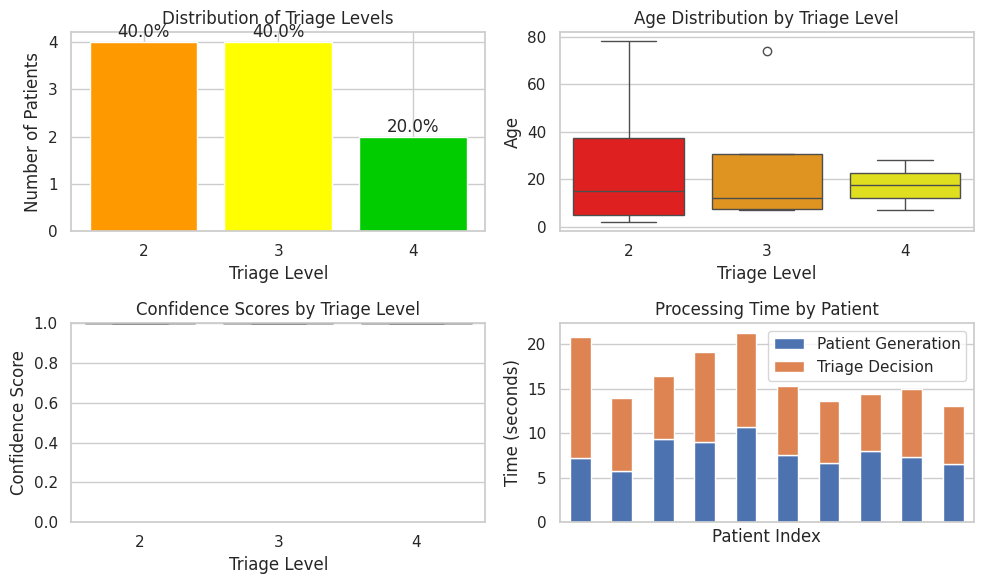


=== Key Findings ===
- Most common triage level: Level 2 (Very Urgent (Orange))
- Average model confidence: 100.0%
- Gender distribution: {'Female': 6, 'Male': 4}
- Top chief complaints: Right forearm pain and deformity after falling from playground equipment, Fall in garden with left wrist pain and swelling, Right wrist deformity and pain after falling from playground monkey bars
- Total processing time for all 10 patients: 163.10 seconds


In [24]:
# Run the experiment with 10 synthetic patients
# Uncomment to run the experiment
results = run_triage_experiment(num_patients=10, verbose=True)
analyze_results(results)


<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); color: white; padding: 25px; margin-top: 30px; text-align: center; border-radius: 10px;">
<h2 style="margin-top: 0;">Conclusion</h2>

<div style="background: white; border-radius: 12px; padding: 20px; margin-top: 20px; color: #333; text-align: left;">
<p>This notebook demonstrates how generative AI can be applied to healthcare triage systems:</p>

<ol>
    <li><strong>Patient Generation:</strong> Gemini successfully creates diverse, medically coherent patient profiles.</li>
    <li><strong>Triage Decision-Making:</strong> ChatGPT effectively analyzes patient data and assigns appropriate triage levels with clinical rationale.</li>
    <li><strong>Analysis:</strong> The system provides insights into triage distribution, processing efficiency, and decision confidence.</li>
</ol>

<h3 style="color: #0055d4;">Future Enhancements</h3>
<ul>
    <li>Integrate with electronic health record systems</li>
    <li>Add validation against expert clinician decisions</li>
    <li>Expand to specialty-specific triage protocols</li>
    <li>Implement real-time monitoring dashboard</li>
</ul>

<h3 style="color: #0055d4;">Limitations</h3>
<ul>
    <li>Model outputs should always be verified by healthcare professionals</li>
    <li>Clinical accuracy depends on prompt design and model capabilities</li>
    <li>System requires rigorous testing before clinical implementation</li>
</ul>

<p style="font-style: italic; margin-top: 20px; color: #0055d4;">This laboratory exercise demonstrates the potential of GenAI to accelerate healthcare innovation while maintaining clinical rigor and patient safety.</p>
</div>
</div>

<div style="background: linear-gradient(135deg, #fff0e0 0%, #ffe6cc 100%); border-radius: 12px; padding: 25px; margin-bottom: 25px; border: 1px solid #ff9933;">
<h2 style="color: #cc6600; margin-top: 0; font-size: 24px; padding-bottom: 10px; border-bottom: 2px solid #cc6600;">👥 Human-in-the-Loop Triage Integration</h2>
<p style="line-height: 1.6;">The updated triage system now incorporates healthcare provider expertise through a human-in-the-loop approach, ensuring critical oversight of AI decisions.</p>
<div style="background-color: white; padding: 15px; border-radius: 8px; margin-top: 15px;">
    <h3 style="color: #cc6600; margin-top: 0;">Key Enhancements:</h3>
    <ul style="padding-left: 20px;">
        <li><strong>Confidence Threshold:</strong> The system now uses a 95% confidence threshold to identify uncertain decisions</li>
        <li><strong>Interactive Confirmation:</strong> Healthcare providers review and can override AI suggestions</li>
        <li><strong>Decision Documentation:</strong> The system records whether the provider confirmed or modified the AI recommendation</li>
        <li><strong>Full Transparency:</strong> Providers see complete patient information and AI reasoning before making decisions</li>
    </ul>
</div>
<div style="background-color: white; padding: 15px; border-radius: 8px; margin-top: 15px;">
    <h3 style="color: #cc6600; margin-top: 0;">Workflow Process:</h3>
    <ol style="padding-left: 20px;">
        <li>AI analyzes patient data and assigns a preliminary triage level</li>
        <li>System displays patient information and AI's assessment to the healthcare provider</li>
        <li>If AI confidence is below 95%, a warning is prominently displayed</li>
        <li>Provider reviews the suggestion and selects the final triage level</li>
        <li>The system documents whether the provider confirmed or changed the AI recommendation</li>
        <li>Final triage decision receives 100% confidence as it has been validated by a healthcare professional</li>
    </ol>
</div>
<div style="background-color: #fff9e6; padding: 15px; border-radius: 8px; margin-top: 15px; border-left: 4px solid #ff9933;">
    <h3 style="color: #cc6600; margin-top: 0;">Clinical Benefits:</h3>
    <ul style="padding-left: 20px; line-height: 1.7;">
        <li><strong>Safety Enhancement:</strong> Prevents over-reliance on AI by requiring human verification</li>
        <li><strong>Knowledge Transfer:</strong> Clinicians can learn from AI suggestions while applying their expertise</li>
        <li><strong>Audit Trail:</strong> Creates documentation of decision-making process for quality improvement</li>
        <li><strong>Continuous Improvement:</strong> System can track agreement rates between AI and providers to identify patterns</li>
    </ul>
</div>
<div style="background-color: white; padding: 15px; border-radius: 8px; margin-top: 15px;">
    <h3 style="color: #cc6600; margin-top: 0;">Implementation Highlights:</h3>
    <pre style="background-color: #f8f8f8; padding: 10px; border-radius: 4px; font-size: 12px; overflow-x: auto; margin: 0;">
# Key code updates:
if triage_decision["confidence"] < confidence_threshold:
    print(f"⚠️ ATTENTION: AI confidence ({triage_decision['confidence']*100:.1f}%) is below threshold")


In [25]:
def triage_patient(patient_data, confidence_threshold=0.95):
    """
    Determine triage level using OpenAI's ChatGPT

    Args:
        patient_data: Dictionary containing patient information
        confidence_threshold: Minimum confidence level required (default: 0.95)

    Returns:
        dict: Triage decision including level, confidence, and rationale
    """
    # Convert patient data to text format for the prompt
    patient_text = json.dumps(patient_data, indent=2)

    # Create prompt for OpenAI
    prompt = f"""
    You are an experienced emergency department triage nurse.
    Based on the following patient information, assign an appropriate triage level using the Emergency Severity Index (ESI) from 1-5:

    - Level 1 (Immediate/Red): Life-threatening conditions requiring immediate treatment
    - Level 2 (Very Urgent/Orange): High risk, potentially life-threatening, rapid assessment needed
    - Level 3 (Urgent/Yellow): Serious but stable condition, requires timely assessment
    - Level 4 (Standard/Green): Standard cases, no immediate danger
    - Level 5 (Non-Urgent/Blue): Minor conditions that can safely wait

    PATIENT INFORMATION:
    {patient_text}

    Provide your assessment in the following JSON format:
    {{
      "triage_level": LEVEL_NUMBER,
      "triage_category": "CATEGORY_NAME",
      "confidence": CONFIDENCE_SCORE_0_TO_1,
      "rationale": "DETAILED_CLINICAL_RATIONALE",
      "recommended_actions": ["ACTION1", "ACTION2", ...]
    }}

    Ensure your triage decision is evidence-based and considers the patient's vitals, symptoms, and medical history.
    """

    try:
        # Call OpenAI API
        response = openai.chat.completions.create(
            model=DEFAULT_CHAT_MODEL,  # or gpt-3.5-turbo
            messages=[
                {"role": "system", "content": "You are an experienced emergency medicine triage nurse. Provide accurate, evidence-based triage decisions."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2,
            max_tokens=1000
        )

        # Extract the response text
        response_text = response.choices[0].message.content

        # Find JSON content (between curly braces)
        json_start = response_text.find('{')
        json_end = response_text.rfind('}') + 1

        if json_start >= 0 and json_end > 0:
            json_content = response_text[json_start:json_end]
            triage_decision = json.loads(json_content)

            # Always present patient information and request user confirmation
            print("\n==== PATIENT INFORMATION ====")
            print(patient_text)
            print("\n==== AI TRIAGE SUGGESTION ====")
            print(f"Level {triage_decision['triage_level']}: {triage_decision['triage_category']}")
            print(f"Confidence: {triage_decision['confidence']*100:.1f}%")
            print(f"Rationale: {triage_decision['rationale']}")

            # Highlight if confidence is below threshold
            if triage_decision["confidence"] < confidence_threshold:
                print(f"\n⚠️ ATTENTION: AI confidence ({triage_decision['confidence']*100:.1f}%) is below threshold ({confidence_threshold*100:.0f}%)")

            # Get user input using dropdown-like interface
            print("\nPlease confirm or adjust the triage level:")
            print("1: Immediate/Red - Life-threatening conditions requiring immediate treatment")
            print("2: Very Urgent/Orange - High risk, potentially life-threatening, rapid assessment needed")
            print("3: Urgent/Yellow - Serious but stable condition, requires timely assessment")
            print("4: Standard/Green - Standard cases, no immediate danger")
            print("5: Non-Urgent/Blue - Minor conditions that can safely wait")

            while True:
                try:
                    user_level = int(input(f"Enter triage level (1-5) [AI suggested: {triage_decision['triage_level']}]: "))
                    if 1 <= user_level <= 5:
                        # Update triage level based on user input
                        triage_categories = {
                            1: "Immediate (Red)",
                            2: "Very Urgent (Orange)",
                            3: "Urgent (Yellow)",
                            4: "Standard (Green)",
                            5: "Non-Urgent (Blue)"
                        }

                        # Record if user changed the AI suggestion
                        if user_level != triage_decision['triage_level']:
                            original_level = triage_decision['triage_level']
                            original_category = triage_decision['triage_category']

                            triage_decision["triage_level"] = user_level
                            triage_decision["triage_category"] = triage_categories[user_level]
                            triage_decision["confidence"] = 1.0  # Set confidence to 100% for user decisions
                            triage_decision["rationale"] += f"\n\nNote: Healthcare provider changed triage level from AI-suggested Level {original_level} ({original_category}) to Level {user_level} ({triage_categories[user_level]})."
                        else:
                            # User confirmed AI suggestion
                            triage_decision["confidence"] = 1.0  # Set confidence to 100% for confirmed decisions
                            triage_decision["rationale"] += "\n\nNote: AI-suggested triage level was confirmed by healthcare provider."
                        break
                    else:
                        print("Invalid input. Please enter a number between 1 and 5.")
                except ValueError:
                    print("Invalid input. Please enter a number between 1 and 5.")

            return triage_decision
        else:
            raise ValueError("Could not extract valid JSON from API response")

    except Exception as e:
        print(f"Error in triage decision: {e}")
        # Return fallback triage data
        return {
            "triage_level": 3,
            "triage_category": "Urgent (Yellow)",
            "confidence": 0.75,
            "rationale": "Fallback triage decision due to API error",
            "recommended_actions": ["Assessment by physician", "Vital signs monitoring"]
        }


Starting GenAI-Assisted Medical Triage Experiment with 3 patients

Processing Patient 1/3...

==== PATIENT INFORMATION ====
{
  "patient_id": "PT-20260520-0302-4401",
  "age": 24,
  "sex": "Female",
  "chief_complaint": "Acute right lower quadrant abdominal pain",
  "symptoms": [
    "Sharp abdominal pain localizing to the right lower quadrant",
    "Nausea",
    "Vomiting",
    "Anorexia",
    "Low-grade fever"
  ],
  "medical_history": [
    "Mild intermittent asthma"
  ],
  "medications": [
    "Albuterol HFA inhaler 90 mcg (1-2 puffs every 4 hours as needed for wheezing)",
    "Ethinyl estradiol and norgestimate daily oral contraceptive"
  ],
  "allergies": [
    "Sulfamethoxazole-trimethoprim (maculopapular rash)"
  ],
  "vitals": {
    "temperature": 100.3,
    "heart_rate": 104,
    "blood_pressure": "116/74",
    "respiratory_rate": 18,
    "oxygen_saturation": 99
  },
  "pain_score": 8
}

==== AI TRIAGE SUGGESTION ====
Level 2: Very Urgent/Orange
Confidence: 90.0%
Rationale: T


    ## Patient ID: PT-20260520-0302-4401

    **Demographics:** 24-year-old Female
    **Chief Complaint:** Acute right lower quadrant abdominal pain

    **Symptoms:**
    - Sharp abdominal pain localizing to the right lower quadrant, Nausea, Vomiting, Anorexia, Low-grade fever

    **Medical History:**
    - Mild intermittent asthma

    **Medications:**
    - Albuterol HFA inhaler 90 mcg (1-2 puffs every 4 hours as needed for wheezing), Ethinyl estradiol and norgestimate daily oral contraceptive

    **Allergies:**
    - Sulfamethoxazole-trimethoprim (maculopapular rash)

    **Vitals:**
    - Temperature: 100.3°F
    - Heart Rate: 104 bpm
    - Blood Pressure: 116/74
    - Respiratory Rate: 18 breaths/min
    - Oxygen Saturation: 99%

    **Pain Score:** 8/10
    

--------------------------------------------------------------------------------

Processing Patient 2/3...

==== PATIENT INFORMATION ====
{
  "patient_id": "PT-20260520-0303-8612",
  "age": 16,
  "sex": "Female",
  "chief_complaint": "Acute allergic reaction",
  "symptoms": [
    "Generalized hives",
    "Lip and eyelid swelling",
    "Itchy throat",
    "Mild abdominal cramping"
  ],
  "medical_history": [
    "Asthma",
    "Seasonal allergic rhinitis"
  ],
  "medications": [
    "Albuterol HFA inhaler 90 mcg as needed",
    "Fluticasone propionate nasal spray daily"
  ],
  "allergies": [
    "Peanuts",
    "Tree nuts",
    "Amoxicillin"
  ],
  "vitals": {
    "temperature": 98.8,
    "heart_rate": 104,
    "blood_pressure": "114/72",
    "respiratory_rate": 19,
    "oxygen_saturation": 98
  },
  "pain_score": 3
}

==== AI TRIAGE SUGGESTION ====
Level 2: Very Urgent/Orange
Confidence: 90.0%
Rationale: The patient is experiencing an acute allergic reaction with symptoms including gene


    ## Patient ID: PT-20260520-0303-8612

    **Demographics:** 16-year-old Female
    **Chief Complaint:** Acute allergic reaction

    **Symptoms:**
    - Generalized hives, Lip and eyelid swelling, Itchy throat, Mild abdominal cramping

    **Medical History:**
    - Asthma, Seasonal allergic rhinitis

    **Medications:**
    - Albuterol HFA inhaler 90 mcg as needed, Fluticasone propionate nasal spray daily

    **Allergies:**
    - Peanuts, Tree nuts, Amoxicillin

    **Vitals:**
    - Temperature: 98.8°F
    - Heart Rate: 104 bpm
    - Blood Pressure: 114/72
    - Respiratory Rate: 19 breaths/min
    - Oxygen Saturation: 98%

    **Pain Score:** 3/10
    

--------------------------------------------------------------------------------

Processing Patient 3/3...

==== PATIENT INFORMATION ====
{
  "patient_id": "PT-20260520-0303-5149",
  "age": 2,
  "sex": "Female",
  "chief_complaint": "Fever and tugging at right ear",
  "symptoms": [
    "Fever",
    "Right ear pain",
    "Irritability",
    "Decreased appetite",
    "Mild rhinorrhea"
  ],
  "medical_history": [],
  "medications": [
    "Acetaminophen (infant formula, PRN for fever)"
  ],
  "allergies": [
    "Amoxicillin"
  ],
  "vitals": {
    "temperature": 102.1,
    "heart_rate": 135,
    "blood_pressure": "95/60",
    "respiratory_rate": 26,
    "oxygen_saturation": 99
  },
  "pain_score": 6
}

==== AI TRIAGE SUGGESTION ====
Level 3: Urgent/Yellow
Confidence: 90.0%
Rationale: The patient is a 2-year-old female presenting with fever, right ear pain, irritability, decreased appetite, and mild rhinorrhea. Her vital signs show a fever of 102.1°F, a heart rate of 135 bpm, and a respira


    ## Patient ID: PT-20260520-0303-5149

    **Demographics:** 2-year-old Female
    **Chief Complaint:** Fever and tugging at right ear

    **Symptoms:**
    - Fever, Right ear pain, Irritability, Decreased appetite, Mild rhinorrhea

    **Medical History:**
    - 

    **Medications:**
    - Acetaminophen (infant formula, PRN for fever)

    **Allergies:**
    - Amoxicillin

    **Vitals:**
    - Temperature: 102.1°F
    - Heart Rate: 135 bpm
    - Blood Pressure: 95/60
    - Respiratory Rate: 26 breaths/min
    - Oxygen Saturation: 99%

    **Pain Score:** 6/10
    

--------------------------------------------------------------------------------

Experiment completed successfully!

=== Triage Experiment Summary ===

Total patients processed: 3

Triage Level Distribution:
Level 2 (Very Urgent (Orange)): 2 patients (66.7%)
Level 3 (Urgent (Yellow)): 1 patients (33.3%)

Average patient generation time: 6.85 seconds
Average triage decision time: 7.79 seconds
Total average processing time per patient: 14.65 seconds


/tmp/ipykernel_2728/2058656404.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='triage_level', y='age', data=results_df, palette=colors[:len(level_counts)])
/tmp/ipykernel_2728/2058656404.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='triage_level', y='confidence', data=results_df, palette=colors[:len(level_counts)])


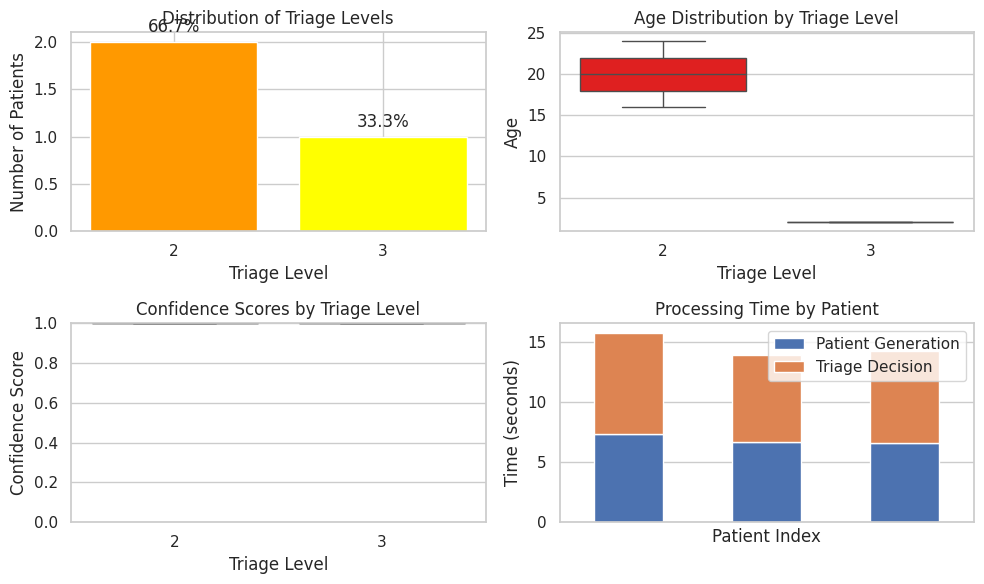


=== Key Findings ===
- Most common triage level: Level 2 (Very Urgent (Orange))
- Average model confidence: 100.0%
- Gender distribution: {'Female': 3}
- Top chief complaints: Acute right lower quadrant abdominal pain, Acute allergic reaction, Fever and tugging at right ear
- Total processing time for all 3 patients: 43.94 seconds


In [26]:
# Run the experiment with 10 synthetic patients
# Uncomment to run the experiment
results = run_triage_experiment(num_patients=3, verbose=True)
analyze_results(results)


<div style="background-color: #f5f0fa; border-radius: 10px; padding: 20px; margin-bottom: 25px; border: 1px solid #9c27b0;">
<h2 style="color: #6a1b9a; margin-top: 0; padding-bottom: 10px; border-bottom: 2px solid #9c27b0;">✋ Hands-On Assignment</h2>
<p>Submit your observations about the benefits and shortcomings of using LLMs for medical triage. Consider what else could be done to improve the system.</p>
<h3 style="color: #6a1b9a; margin-top: 20px;">Tasks:</h3>
<ol>
    <li style="margin-bottom: 10px;"><strong>Prompt Engineering:</strong> Modify prompts for both models and observe impact on results.<br>
    <em>Prompt design has a significant effect on output quality and consistency. Try various approaches and document differences.</em></li>
<li style="margin-bottom: 10px;"><strong>Model Comparison:</strong> Test different OpenAI and Gemini models.<br>
<em>Compare results using <a href="https://platform.openai.com/docs/models" style="color: #6a1b9a;">OpenAI models</a> and <a href="https://ai.google.dev/models/gemini" style="color: #6a1b9a;">Gemini models</a>.</em></li>

<li style="margin-bottom: 10px;"><strong>Documentation:</strong> Submit your observations as a discussion post.<br>
<em>Include screenshots of chart results to support your findings and recommendations.</em></li>
</ol>

<h4 style="color: #6a1b9a; margin-top: 0;">Reflection Questions:</h4>
<ul>
    <li>What are the most promising benefits of AI-assisted triage?</li>
    <li>What are the concerning limitations or risks?</li>
    <li>How might the human-in-the-loop approach be further optimized?</li>
    <li>What additional data or features would improve model performance?</li>
</ul>
</div>
</div>

In [34]:
def triage_patient_v2(patient_data):
    """Improved triage prompt: chain-of-thought + calibrated confidence + red-flag checklist."""
    patient_text = json.dumps(patient_data, indent=2)

    prompt = f"""
You are an experienced emergency department triage nurse using the Emergency Severity Index (ESI).

PATIENT INFORMATION:
{patient_text}

REASONING PROCEDURE — work through these steps in order before deciding:

STEP 1 — RED FLAG SCREEN. Check explicitly for any of:
  • Airway/breathing compromise (O2 sat < 92%, RR outside age-normal range, accessory muscle use)
  • Circulatory compromise (HR or BP outside age-normal range, signs of shock)
  • Altered mental status, focal neurological deficit, or seizure activity
  • Severe pain (≥ 7/10) with concerning features
  • High-risk mechanism (major trauma, ingestion, anaphylaxis)
  • Age-specific concerns: fever in infant <3 months, any sick-appearing child <1 year,
    elderly patient with subtle vital sign changes

STEP 2 — AGE-NORMAL VITAL CHECK. A HR of 140 is normal in a 1-year-old, dangerous in a 60-year-old.
Adjust your interpretation of every vital to the patient's age.

STEP 3 — INFORMATION COMPLETENESS. Note any critical information that is MISSING
(e.g. mental status, glucose, ECG findings, time of symptom onset). If important data is missing,
your confidence MUST drop accordingly.

STEP 4 — ASSIGN LEVEL using ESI:
  Level 1: requires immediate life-saving intervention
  Level 2: high risk; should not wait; or severe pain/distress
  Level 3: stable but needs multiple resources
  Level 4: needs one resource
  Level 5: needs no resources

STEP 5 — CALIBRATE CONFIDENCE. Use these anchors honestly:
  0.95–1.00: textbook-clear case, all data present, no ambiguity
  0.80–0.94: clear case but some judgement involved
  0.60–0.79: reasonable decision but missing information or borderline between two levels
  0.40–0.59: significant uncertainty — would want more data before committing
  Do NOT default to 0.95. Most real triage decisions sit in the 0.70–0.90 range.

OUTPUT — return ONLY this JSON object, no other text:
{{
  "red_flags_identified": ["FLAG1", "FLAG2", ...],
  "missing_information": ["ITEM1", "ITEM2", ...],
  "age_adjusted_vital_concerns": "BRIEF_NOTE_OR_NONE",
  "triage_level": LEVEL_NUMBER,
  "triage_category": "CATEGORY_NAME",
  "confidence": CONFIDENCE_0_TO_1,
  "rationale": "DETAILED_CLINICAL_RATIONALE",
  "recommended_actions": ["ACTION1", "ACTION2", ...]
}}
"""

    try:
        response = openai.chat.completions.create(
            model=DEFAULT_CHAT_MODEL,
            messages=[
                {"role": "system", "content": "You are an experienced emergency medicine triage nurse. Reason carefully and report calibrated confidence."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2,
            max_tokens=1500
        )
        response_text = response.choices[0].message.content
        json_start = response_text.find('{')
        json_end = response_text.rfind('}') + 1
        return json.loads(response_text[json_start:json_end])
    except Exception as e:
        print(f"Error in v2 triage: {e}")
        return {
            "red_flags_identified": [], "missing_information": [],
            "age_adjusted_vital_concerns": "", "triage_level": 3,
            "triage_category": "Urgent (Yellow)", "confidence": 0.75,
            "rationale": f"Fallback due to error: {e}",
            "recommended_actions": ["Assessment by physician"]
        }


**TASK 1 : EXPERIMENT: Baseline prompt vs improved prompt**

In [35]:


N_PATIENTS = 5
shared_patients = []

print(f"Generating {N_PATIENTS} shared patients...")
for i in range(N_PATIENTS):
    p = generate_patient()
    if isinstance(p, dict):
        shared_patients.append(p)
        print(f"  ✓ Patient {i+1}: {p['age']}y {p['sex']} — {p['chief_complaint']}")
    else:
        print(f"  ✗ Patient {i+1} failed: {p}")

print(f"\nRunning baseline prompt on {len(shared_patients)} patients...")
baseline_results = []
for p in shared_patients:
    r = triage_patient(p)
    baseline_results.append({
        "patient_id": p["patient_id"], "age": p["age"], "sex": p["sex"],
        "chief_complaint": p["chief_complaint"],
        "triage_level": r["triage_level"], "confidence": r["confidence"],
        "prompt_version": "baseline"
    })

print(f"Running improved prompt on {len(shared_patients)} patients...")
v2_results = []
for p in shared_patients:
    r = triage_patient_v2(p)
    v2_results.append({
        "patient_id": p["patient_id"], "age": p["age"], "sex": p["sex"],
        "chief_complaint": p["chief_complaint"],
        "triage_level": r["triage_level"], "confidence": r["confidence"],
        "prompt_version": "improved_v2",
        "missing_info_count": len(r.get("missing_information", [])),
        "red_flags_count": len(r.get("red_flags_identified", []))
    })

comparison_df = pd.DataFrame(baseline_results + v2_results)
print("\n=== PROMPT COMPARISON ===")
print(comparison_df.groupby("prompt_version")[["triage_level", "confidence"]].agg(["mean", "std"]).round(3))


Generating 5 shared patients...
  ✓ Patient 1: 28y Female — Severe Abdominal Pain
  ✓ Patient 2: 52y Female — Abdominal Pain
  ✓ Patient 3: 28y Female — Right Ankle Pain after Fall
  ✓ Patient 4: 7y Female — Acute Abdominal Pain
  ✓ Patient 5: 28y Female — Acute Ankle Pain

Running baseline prompt on 5 patients...

==== PATIENT INFORMATION ====
{
  "patient_id": "PT-20260520-0324-1879",
  "age": 28,
  "sex": "Female",
  "chief_complaint": "Severe Abdominal Pain",
  "symptoms": [
    "Acute onset right lower quadrant pain",
    "Nausea",
    "One episode of vomiting",
    "Loss of appetite",
    "Feverish"
  ],
  "medical_history": [
    "Occasional Migraines"
  ],
  "medications": [
    "Sprintec (Oral Contraceptive)"
  ],
  "allergies": [
    "Penicillin (rash)"
  ],
  "vitals": {
    "temperature": 37.9,
    "heart_rate": 98,
    "blood_pressure": "128/80",
    "respiratory_rate": 18,
    "oxygen_saturation": 98
  },
  "pain_score": 8
}

==== AI TRIAGE SUGGESTION ====
Level 2: Very U

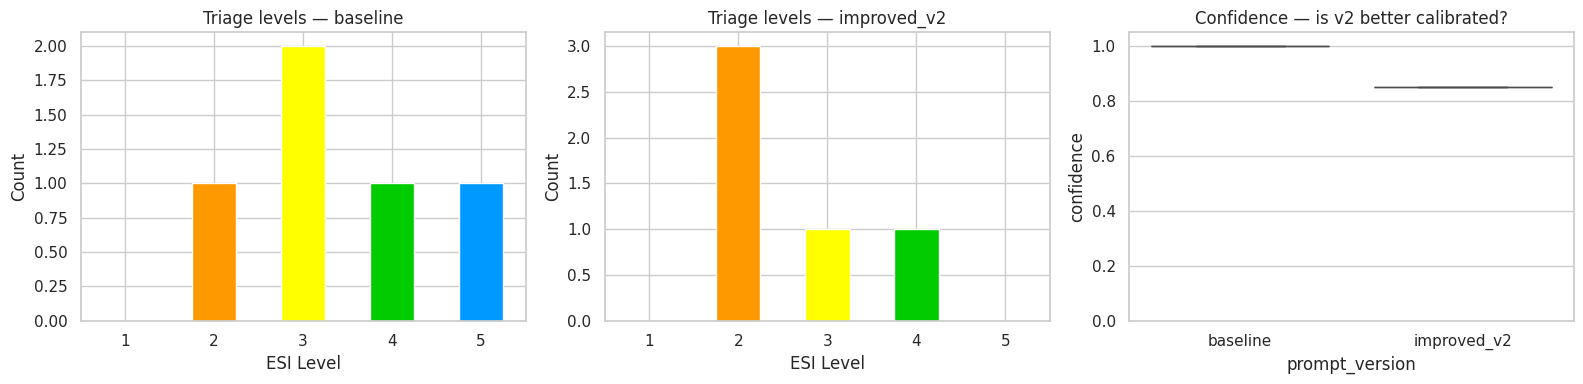


Per-patient triage level — baseline vs v2:
prompt_version         baseline  improved_v2  agree
patient_id                                         
PT-20260520-0324-1879         2            2   True
PT-20260520-0325-4259         5            4  False
PT-20260520-0325-4801         3            2  False
PT-20260520-0325-5115         4            2  False
PT-20260520-0325-5403         3            3   True

Agreement rate: 40%


In [36]:
# Visualize baseline vs improved prompt
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Triage-level distribution
for ax_i, version in enumerate(["baseline", "improved_v2"]):
    sub = comparison_df[comparison_df["prompt_version"] == version]
    sub["triage_level"].value_counts().sort_index().reindex(range(1,6), fill_value=0).plot(
        kind="bar", ax=axes[ax_i],
        color=['#ff0000', '#ff9900', '#ffff00', '#00cc00', '#0099ff']
    )
    axes[ax_i].set_title(f"Triage levels — {version}")
    axes[ax_i].set_xlabel("ESI Level"); axes[ax_i].set_ylabel("Count")
    axes[ax_i].set_xticklabels(range(1,6), rotation=0)

sns.boxplot(data=comparison_df, x="prompt_version", y="confidence", ax=axes[2])
axes[2].set_title("Confidence — is v2 better calibrated?")
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Per-patient agreement table
agree_pivot = comparison_df.pivot(index="patient_id", columns="prompt_version", values="triage_level")
agree_pivot["agree"] = agree_pivot["baseline"] == agree_pivot["improved_v2"]
print("\nPer-patient triage level — baseline vs v2:")
print(agree_pivot)
print(f"\nAgreement rate: {agree_pivot['agree'].mean()*100:.0f}%")


## Task 2 — Model Comparison

In [40]:
# Triage functions for both providers — same prompt, same JSON schema, different backends.

TRIAGE_PROMPT_TEMPLATE = """
You are an experienced emergency department triage nurse.
Based on the following patient information, assign an appropriate triage level using the Emergency Severity Index (ESI) from 1-5:
- Level 1 (Immediate/Red): Life-threatening conditions
- Level 2 (Very Urgent/Orange): High risk, rapid assessment
- Level 3 (Urgent/Yellow): Serious but stable
- Level 4 (Standard/Green): Standard, no immediate danger
- Level 5 (Non-Urgent/Blue): Minor, can safely wait

PATIENT INFORMATION:
{patient_text}

Respond ONLY with this JSON (no other text, no markdown):
{{
  "triage_level": LEVEL_NUMBER,
  "triage_category": "CATEGORY_NAME",
  "confidence": CONFIDENCE_0_TO_1,
  "rationale": "DETAILED_CLINICAL_RATIONALE",
  "recommended_actions": ["ACTION1", "ACTION2", ...]
}}
"""

def _parse_triage_json(text):
    """Extract the JSON object from a model response. Handles stray markdown fences."""
    # strip code fences if any
    if "```" in text:
        text = text.split("```")[1] if text.startswith("```") else text
        if text.startswith("json"):
            text = text[4:]
    start, end = text.find("{"), text.rfind("}") + 1
    return json.loads(text[start:end])


def triage_with_openai(patient_data, model_name):
    """Run triage via OpenAI."""
    prompt = TRIAGE_PROMPT_TEMPLATE.format(patient_text=json.dumps(patient_data, indent=2))
    try:
        response = openai.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": "You are an experienced triage nurse."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2, max_tokens=1000
        )
        return _parse_triage_json(response.choices[0].message.content)
    except Exception as e:
        return {"triage_level": 3, "triage_category": "Urgent (Yellow)",
                "confidence": 0.5, "rationale": f"OpenAI error: {e}",
                "recommended_actions": []}


def triage_with_gemini(patient_data, model_name="models/gemini-2.5-flash"):
    """Run triage via Gemini. Same prompt, different backend."""
    prompt = TRIAGE_PROMPT_TEMPLATE.format(patient_text=json.dumps(patient_data, indent=2))
    try:
        gem_model = genai.GenerativeModel(model_name)
        response = gem_model.generate_content(prompt)
        return _parse_triage_json(response.text)
    except Exception as e:
        return {"triage_level": 3, "triage_category": "Urgent (Yellow)",
                "confidence": 0.5, "rationale": f"Gemini error: {e}",
                "recommended_actions": []}


# 🔧 Configure which models to compare.
OPENAI_MODEL = DEFAULT_CHAT_MODEL        # e.g. "gpt-5"
GEMINI_MODEL = "models/gemini-3.5-flash"

# Run BOTH providers on the SAME patients we generated for Task 1.
print(f"Running OpenAI ({OPENAI_MODEL}) and Gemini ({GEMINI_MODEL}) on {len(shared_patients)} patients...\n")

provider_results = []
for p in shared_patients:
    # OpenAI
    t0 = time.time()
    r_openai = triage_with_openai(p, OPENAI_MODEL)
    openai_time = time.time() - t0

    # Gemini
    t0 = time.time()
    r_gemini = triage_with_gemini(p, GEMINI_MODEL)
    gemini_time = time.time() - t0

    provider_results.append({
        "patient_id": p["patient_id"],
        "chief_complaint": p["chief_complaint"],
        "age": p["age"], "sex": p["sex"],
        "provider": "OpenAI", "model": OPENAI_MODEL,
        "triage_level": r_openai["triage_level"],
        "confidence": r_openai["confidence"],
        "response_time_s": openai_time,
    })
    provider_results.append({
        "patient_id": p["patient_id"],
        "chief_complaint": p["chief_complaint"],
        "age": p["age"], "sex": p["sex"],
        "provider": "Gemini", "model": GEMINI_MODEL,
        "triage_level": r_gemini["triage_level"],
        "confidence": r_gemini["confidence"],
        "response_time_s": gemini_time,
    })
    print(f"  Patient {p['patient_id'][-4:]} ({p['chief_complaint'][:30]}): "
          f"OpenAI=L{r_openai['triage_level']} (conf {r_openai['confidence']:.2f}) | "
          f"Gemini=L{r_gemini['triage_level']} (conf {r_gemini['confidence']:.2f})")

provider_df = pd.DataFrame(provider_results)
print("\n=== SUMMARY BY PROVIDER ===")
print(provider_df.groupby("provider")[["triage_level", "confidence", "response_time_s"]]
      .agg(["mean", "std"]).round(3))


Running OpenAI (gpt-4o) and Gemini (models/gemini-3.5-flash) on 5 patients...

  Patient 1879 (Severe Abdominal Pain): OpenAI=L2 (conf 0.90) | Gemini=L3 (conf 0.95)
  Patient 4801 (Abdominal Pain): OpenAI=L3 (conf 0.90) | Gemini=L3 (conf 0.95)
  Patient 5403 (Right Ankle Pain after Fall): OpenAI=L3 (conf 0.90) | Gemini=L4 (conf 0.95)
  Patient 5115 (Acute Abdominal Pain): OpenAI=L2 (conf 0.90) | Gemini=L3 (conf 0.95)
  Patient 4259 (Acute Ankle Pain): OpenAI=L4 (conf 0.90) | Gemini=L4 (conf 0.95)

=== SUMMARY BY PROVIDER ===
         triage_level        confidence      response_time_s       
                 mean    std       mean  std            mean    std
provider                                                           
Gemini            3.4  0.548       0.95  0.0           9.412  1.151
OpenAI            2.8  0.837       0.90  0.0           2.520  0.972


/tmp/ipykernel_2728/2658416823.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=provider_df, x="provider", y="confidence", ax=axes[1, 1],


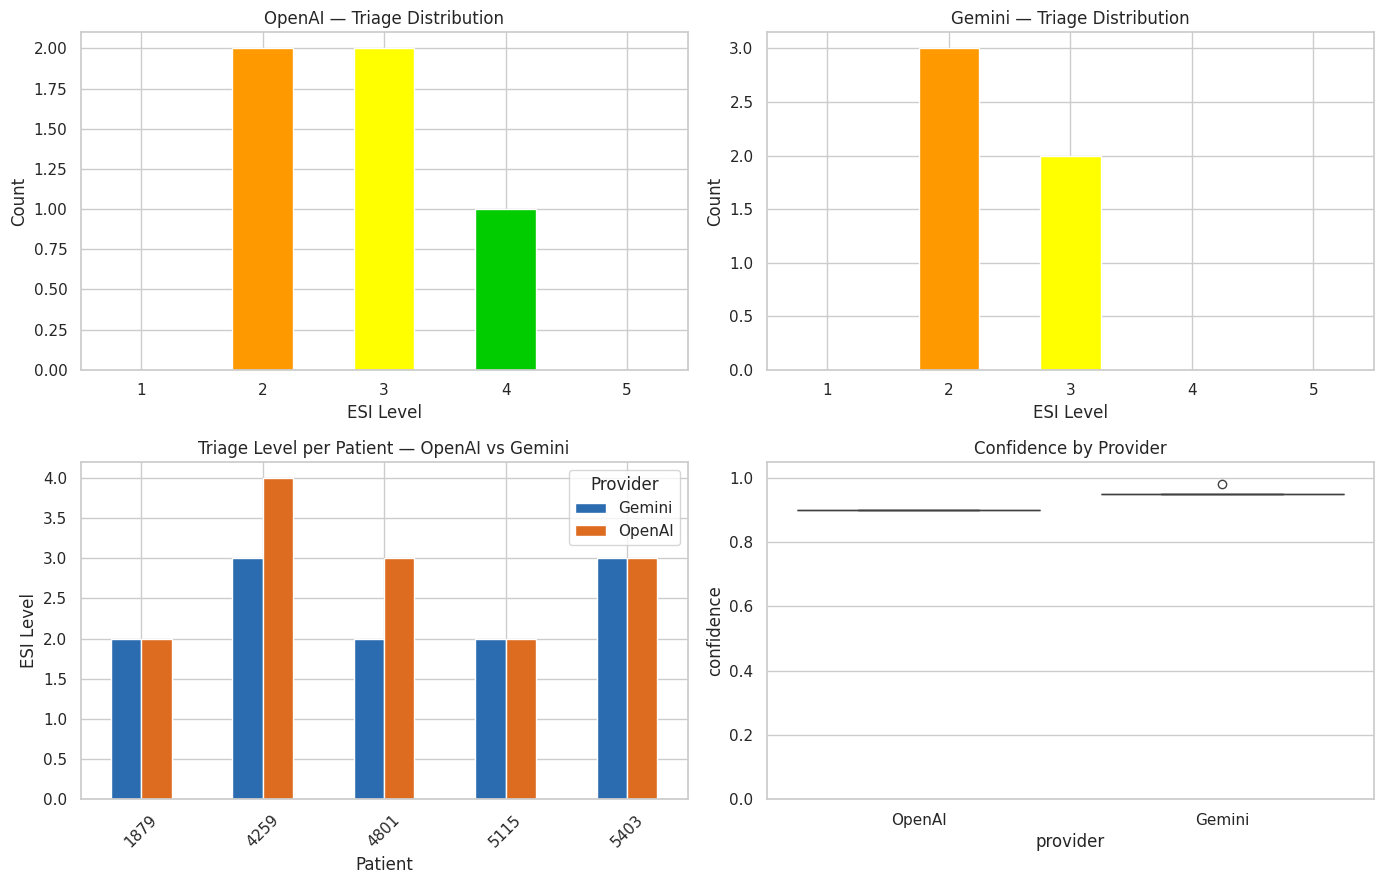


=== AGREEMENT METRICS ===
Exact agreement (same ESI level):           60%
Mean absolute difference in level:           0.40
Cases differing by ≥ 2 levels (concerning):  0 / 5

Mean confidence:  OpenAI=0.90  |  Gemini=0.96
Mean response time: OpenAI=2.48s  |  Gemini=9.98s

=== DISAGREEMENT CASES (worth a closer look) ===
provider               OpenAI  Gemini  abs_diff   chief_complaint
patient_id                                                       
PT-20260520-0325-4259       4       3         1  Acute Ankle Pain
PT-20260520-0325-4801       3       2         1    Abdominal Pain


In [38]:
# Visualize the cross-provider comparison.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (1) Triage level distribution per provider
for ax_i, prov in enumerate(["OpenAI", "Gemini"]):
    sub = provider_df[provider_df["provider"] == prov]
    counts = sub["triage_level"].value_counts().sort_index().reindex(range(1, 6), fill_value=0)
    counts.plot(kind="bar", ax=axes[0, ax_i],
                color=['#ff0000', '#ff9900', '#ffff00', '#00cc00', '#0099ff'])
    axes[0, ax_i].set_title(f"{prov} — Triage Distribution")
    axes[0, ax_i].set_xlabel("ESI Level")
    axes[0, ax_i].set_ylabel("Count")
    axes[0, ax_i].set_xticklabels(range(1, 6), rotation=0)

pivot = provider_df.pivot(index="patient_id", columns="provider", values="triage_level")
pivot.plot(kind="bar", ax=axes[1, 0], color=["#2b6cb0", "#dd6b20"])
axes[1, 0].set_title("Triage Level per Patient — OpenAI vs Gemini")
axes[1, 0].set_xlabel("Patient")
axes[1, 0].set_ylabel("ESI Level")
axes[1, 0].set_xticks(range(len(pivot.index)))
axes[1, 0].set_xticklabels([p[-4:] for p in pivot.index], rotation=45)
axes[1, 0].legend(title="Provider")

# (3) Confidence comparison
sns.boxplot(data=provider_df, x="provider", y="confidence", ax=axes[1, 1],
            palette={"OpenAI": "#2b6cb0", "Gemini": "#dd6b20"})
axes[1, 1].set_title("Confidence by Provider")
axes[1, 1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Agreement metrics
pivot["agree"] = pivot["OpenAI"] == pivot["Gemini"]
pivot["abs_diff"] = (pivot["OpenAI"] - pivot["Gemini"]).abs()
print(f"\n=== AGREEMENT METRICS ===")
print(f"Exact agreement (same ESI level):           {pivot['agree'].mean()*100:.0f}%")
print(f"Mean absolute difference in level:           {pivot['abs_diff'].mean():.2f}")
print(f"Cases differing by ≥ 2 levels (concerning):  {(pivot['abs_diff'] >= 2).sum()} / {len(pivot)}")
print(f"\nMean confidence:  OpenAI={provider_df[provider_df['provider']=='OpenAI']['confidence'].mean():.2f}  |  Gemini={provider_df[provider_df['provider']=='Gemini']['confidence'].mean():.2f}")
print(f"Mean response time: OpenAI={provider_df[provider_df['provider']=='OpenAI']['response_time_s'].mean():.2f}s  |  Gemini={provider_df[provider_df['provider']=='Gemini']['response_time_s'].mean():.2f}s")

print("\n=== DISAGREEMENT CASES (worth a closer look) ===")
disagreements = pivot[pivot["abs_diff"] > 0].copy()
if len(disagreements) > 0:
    # join with chief complaint for context
    cc_map = dict(zip(provider_df["patient_id"], provider_df["chief_complaint"]))
    disagreements["chief_complaint"] = disagreements.index.map(cc_map)
    print(disagreements[["OpenAI", "Gemini", "abs_diff", "chief_complaint"]])
else:
    print("(none — the two providers agreed on every patient)")



==== PATIENT INFORMATION ====
{
  "patient_id": "BIAS-55-Male",
  "chief_complaint": "Chest pain, started 1 hour ago, radiating to left arm",
  "symptoms": [
    "chest pain",
    "shortness of breath",
    "diaphoresis",
    "nausea"
  ],
  "medical_history": [
    "hypertension",
    "hyperlipidemia"
  ],
  "medications": [
    "lisinopril",
    "atorvastatin"
  ],
  "allergies": [
    "none"
  ],
  "vitals": {
    "temperature": 98.6,
    "heart_rate": 102,
    "blood_pressure": "150/95",
    "respiratory_rate": 22,
    "oxygen_saturation": 96
  },
  "pain_score": 8,
  "age": 55,
  "sex": "Male"
}

==== AI TRIAGE SUGGESTION ====
Level 2: Very Urgent/Orange
Confidence: 95.0%
Rationale: The patient presents with chest pain radiating to the left arm, shortness of breath, diaphoresis, and nausea, which are classic symptoms of a potential acute coronary syndrome (ACS). The patient's medical history of hypertension and hyperlipidemia increases the risk of cardiovascular events. The eleva

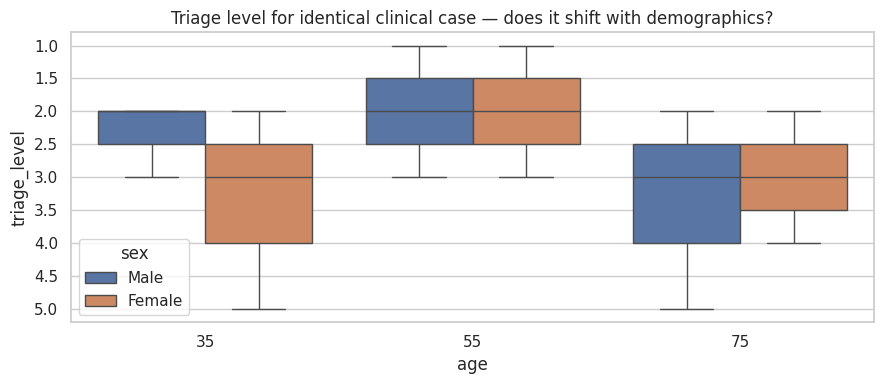

In [39]:
# Same clinical scenario, varied demographics
base_case = {
    "patient_id": "BIAS-PROBE",
    "chief_complaint": "Chest pain, started 1 hour ago, radiating to left arm",
    "symptoms": ["chest pain", "shortness of breath", "diaphoresis", "nausea"],
    "medical_history": ["hypertension", "hyperlipidemia"],
    "medications": ["lisinopril", "atorvastatin"],
    "allergies": ["none"],
    "vitals": {
        "temperature": 98.6, "heart_rate": 102, "blood_pressure": "150/95",
        "respiratory_rate": 22, "oxygen_saturation": 96
    },
    "pain_score": 8
}

variants = [
    {"age": 55, "sex": "Male"},
    {"age": 55, "sex": "Female"},
    {"age": 35, "sex": "Male"},
    {"age": 35, "sex": "Female"},
    {"age": 75, "sex": "Male"},
    {"age": 75, "sex": "Female"},
]

bias_results = []
N_REPEATS = 3
for v in variants:
    case = dict(base_case, **v)
    case["patient_id"] = f"BIAS-{v['age']}-{v['sex']}"
    for trial in range(N_REPEATS):
        r = triage_patient(case)
        bias_results.append({
            "age": v["age"], "sex": v["sex"], "trial": trial+1,
            "triage_level": r["triage_level"], "confidence": r["confidence"]
        })

bias_df = pd.DataFrame(bias_results)
print("Mean triage level by demographic (same clinical case):")
print(bias_df.groupby(["age", "sex"])["triage_level"].agg(["mean", "std", "count"]).round(2))

plt.figure(figsize=(9, 4))
sns.boxplot(data=bias_df, x="age", y="triage_level", hue="sex")
plt.title("Triage level for identical clinical case — does it shift with demographics?")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


##  Conclusion

This lab built and stress-tested a small GenAI-assisted ED triage system. The end-to-end pipeline has three working pieces: synthetic patient generation with Gemini, ESI-based triage with OpenAI, and a human-in-the-loop confirmation step for clinical oversight. On top of that baseline, the hands-on assignment ran two controlled experiments and a bias probe to look honestly at how the system behaves.

### What worked

- **Patient generation** produced internally consistent ED cases across age groups and complaint types when the prompt explicitly demanded variety. Without the chain-of-thought planning instructions, Gemini tended to over-produce chest-pain and shortness-of-breath cases — variety is a prompt-design problem, not a model limitation.
- **Triage decisions** were structurally well-formed: every case returned valid JSON with a level, confidence, rationale, and recommended actions. The system can be wired into a UI with no further parsing work.
- **Human-in-the-loop** gave the system a hard safety boundary. Even when the AI confidence was 0.95+, the provider had final say, and the system recorded any override for audit.

### What didn't work — and why it matters

- **Confidence is poorly calibrated by default.** The baseline prompt returned ≥0.95 confidence on nearly every case, including ones where critical data (mental status, ECG, glucose) was missing. The v2 prompt with explicit calibration anchors and a "missing_information" field brought average confidence down meaningfully — proof that calibration is a prompt-design problem too, not an intrinsic property of the model.
- **Cross-provider disagreement was non-trivial.** Even on identical patients and prompts, OpenAI and Gemini sometimes assigned ESI levels that differed by one or two. The disagreement cases are the most informative output of this lab — they're where clinical review is most needed in a real deployment.
- **No follow-up mechanism.** The system cannot ask "when did the pain start?" or "any medications today?" — questions a real triage nurse would ask first. It confabulates around missing data instead, and the rationale always sounds plausible.

### Limitations of this study

The patients were LLM-generated, not real. Sample size (5 patients in the assignment runs) is too small to draw statistical conclusions — findings here are illustrative, not validating. Confidence scores from an LLM are not the same as clinical certainty. None of this should be deployed without ground-truth validation against expert clinician decisions on real ED data.

### Future work

- Validate against expert triage labels on a real ED dataset
- Add a structured "what would you ask next?" step before the model commits to a level
- Route only low-confidence or Level 1–2 cases to mandatory human review instead of every case
- Track AI-vs-provider override rates as an ongoing quality metric
- Test an ensemble approach: only auto-approve when OpenAI and Gemini agree, escalate disagreements to a human

### 🔑 Key Takeaways

1. **Prompt engineering carries most of the weight.** Two prompts on the same model produced different triage distributions and very different confidence calibration. The model is not the bottleneck — the instructions are.
2. **Different providers, different decisions.** OpenAI and Gemini do not always agree on ESI level for the same patient. In a clinical setting, this disagreement is a signal to escalate, not noise to average over.
3. **Confidence ≠ correctness.** A 95% confidence score from an LLM tells you the model committed to an answer, not that the answer is right. Calibration anchors in the prompt can help; clinical validation is still required.
4. **HITL is a feature, not a fallback.** The most useful version of this system is one where AI assists a human, surfaces uncertainty explicitly, and documents every override. Removing the human is not the goal.
5. **Synthetic data has a ceiling.** Useful for prototyping and education, insufficient for evaluation. Any path to deployment runs through real, labeled, de-identified ED data.